In [1]:
import os
import subprocess
import glob
import pandas as pd  # Add this since you're using pandas

# Define segmentation parameters
m = 100  # Fixed value for -m
s = 4    # Fixed value for -s

In [2]:
transcripts = pd.read_parquet('/Volumes/Castelo_Branco/NGSDATA/[spatialOmics_CML]MS_spinal_cord_Xenium_human_brain_panel/xenium_datasets-1/output-XETG00045__0003385__inactive__20230510__111824/transcripts.parquet')

In [6]:
transcripts.feature_name = transcripts.feature_name.astype(str)

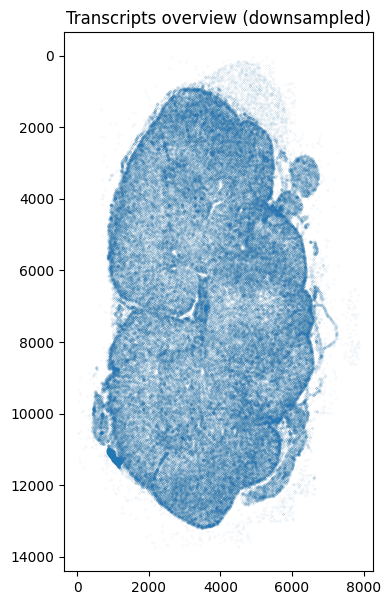

In [13]:
import numpy as np
import matplotlib.pyplot as plt


# column names can vary; try these common ones:
for xcol, ycol in [("x","y"), ("x_centroid","y_centroid"), ("x_location","y_location")]:
    if xcol in transcripts.columns and ycol in transcripts.columns:
        break

# downsample for speed
n = min(len(transcripts), 300_000)
dfp = transcripts.sample(n, random_state=0) if len(transcripts) > n else transcripts

plt.figure(figsize=(7,7))
plt.scatter(dfp[xcol], dfp[ycol], s=0.001)
plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()  # Xenium often looks right with inverted y
plt.title("Transcripts overview (downsampled)")
plt.show()

In [18]:
xmin, xmax = 3000, 6000
ymin, ymax =  5000, 9000

df_roi = transcripts[
    (transcripts["x_location"] >= xmin) & (transcripts["x_location"] <= xmax) &
    (transcripts["y_location"] >= ymin) & (transcripts["y_location"] <= ymax)
].copy()

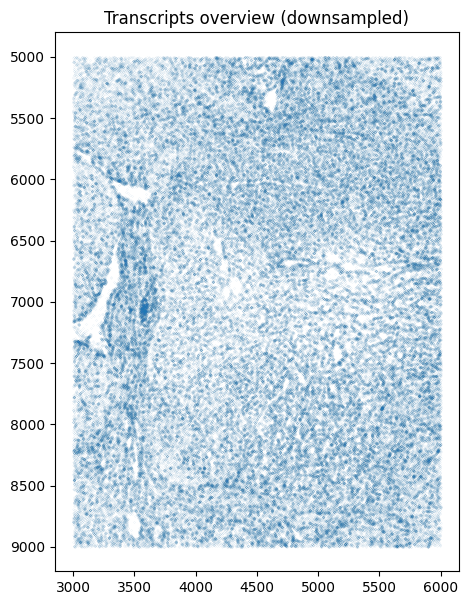

In [19]:
import numpy as np
import matplotlib.pyplot as plt


# column names can vary; try these common ones:
for xcol, ycol in [("x","y"), ("x_centroid","y_centroid"), ("x_location","y_location")]:
    if xcol in df_roi.columns and ycol in df_roi.columns:
        break

# downsample for speed
n = min(len(df_roi), 300_000)
dfp = df_roi.sample(n, random_state=0) if len(df_roi) > n else df_roi

plt.figure(figsize=(7,7))
plt.scatter(dfp[xcol], dfp[ycol], s=0.001)
plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()  # Xenium often looks right with inverted y
plt.title("Transcripts overview (downsampled)")
plt.show()

In [25]:
import re

df_roi_filtered = df_roi[
    ~df_roi["feature_name"].str.contains(
        r"^BLANK_|^NegControlCodeword_|^NegControlProbe_",
        regex=True,
        na=False
    )
].copy()

In [26]:
df_roi_filtered.to_csv('/Volumes/processing2/hm-xenium-ms/baysor_test/ROI-inactive.csv')

In [28]:
df_roi_filtered

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,fov_name,nucleus_distance
7383658,281728379781167,b'hanjofbh-1',1,ST18,3665.528564,5039.370605,18.994442,10.461469,b'O10',0.000000
7383659,281728379781173,b'hankaaeh-1',1,OLIG2,3667.532471,5037.833008,17.599674,30.824772,b'O10',0.000000
7383668,281728379781190,b'hanljmmo-1',0,SAMD5,3676.307373,5006.078125,18.727102,40.000000,b'O10',13.254629
7383669,281728379781191,b'hanljmmo-1',0,ADRA1A,3676.991455,5005.151855,16.182310,40.000000,b'O10',12.228715
7383708,281728379781230,b'alpcangl-1',0,SAMD5,3687.764160,5077.579102,18.930725,40.000000,b'O10',7.727191
...,...,...,...,...,...,...,...,...,...,...
20076448,282071977304938,b'mogbfkep-1',0,SOX9,3648.415527,8979.159180,19.012213,40.000000,b'U9',2.742860
20076449,282071977304939,b'moeabjdp-1',0,MAL,3648.061279,8851.065430,16.874477,40.000000,b'U9',2.094406
20076452,282071977304943,b'mnpklljb-1',0,SERPINA3,3647.832520,8737.907227,17.404404,40.000000,b'U9',2.428513
20076453,282071977304947,b'moeabjdp-1',0,IFITM3,3649.048096,8846.921875,17.730368,40.000000,b'U9',1.348776


In [30]:
import os
import subprocess
import pandas as pd

def run_baysor_single_file(
    input_file,
    m=100,
    s=4,
    xcol="x_location",
    ycol="y_location",
    zcol="z_location",
    genecol="feature_name",
    remove_blank=True,
):
    """
    Clean a detected_transcripts CSV and run Baysor segmentation on it.

    Parameters
    ----------
    input_file : str
        Path to detected_transcripts*.csv
    m, s : int
        Baysor segmentation parameters
    xcol, ycol, zcol, genecol : str
        Column names for Baysor
    remove_blank : bool
        Remove 'Blank' genes before segmentation

    Returns
    -------
    dict
        Paths to cleaned file, output directory, and segmentation result
    """

    if not os.path.exists(input_file):
        raise FileNotFoundError(input_file)

    print(f"📄 Input file: {input_file}")

    dir_name = os.path.dirname(input_file)
    file_name = os.path.splitext(os.path.basename(input_file))[0]

    # ------------------------------------------------------------------
    # 1. Clean transcript file
    # ------------------------------------------------------------------
    cleaned_name = f"{file_name}_cleaned.csv"
    cleaned_path = os.path.join(dir_name, cleaned_name)

    if not os.path.exists(cleaned_path):
        df = pd.read_csv(input_file)
        if remove_blank:
            df = df[~df[genecol].str.contains("Blank", na=False)]
        df.to_csv(cleaned_path, index=False)
        print(f"🧹 Created cleaned file: {cleaned_path}")
    else:
        print(f"⏭️  Using existing cleaned file: {cleaned_path}")

    # ------------------------------------------------------------------
    # 2. Prepare output directory
    # ------------------------------------------------------------------
    output_dir = os.path.join(dir_name, f"m_{m}_s_{s}")
    os.makedirs(output_dir, exist_ok=True)

    result_file = os.path.join(output_dir, "segmentation.csv")

    if os.path.exists(result_file):
        print(f"⏭️  Segmentation already exists: {result_file}")
        return {
            "cleaned_file": cleaned_path,
            "output_dir": output_dir,
            "result_file": result_file,
        }

    # ------------------------------------------------------------------
    # 3. Run Baysor
    # ------------------------------------------------------------------
    command = [
        "baysor", "run", cleaned_path,
        "-x", xcol,
        "-y", ycol,
        "-z", zcol,
        "-g", genecol,
        "-m", str(m),
        "-s", str(s),
        "-o", output_dir,
    ]

    print("🚀 Running Baysor:")
    print("   ", " ".join(command))

    try:
        subprocess.run(command, check=True)
        print(f"✅ Completed: {output_dir}")
    except subprocess.CalledProcessError as e:
        print("❌ Baysor failed")
        raise e

    return {
        "cleaned_file": cleaned_path,
        "output_dir": output_dir,
        "result_file": result_file if os.path.exists(result_file) else None,
    }

In [31]:
result = run_baysor_single_file(
    '/Volumes/processing2/hm-xenium-ms/baysor_test/ROI-inactive.csv',
    m=100,
    s=4,
)

result

📄 Input file: /Volumes/processing2/hm-xenium-ms/baysor_test/ROI-inactive.csv
🧹 Created cleaned file: /Volumes/processing2/hm-xenium-ms/baysor_test/ROI-inactive_cleaned.csv
🚀 Running Baysor:
    baysor run /Volumes/processing2/hm-xenium-ms/baysor_test/ROI-inactive_cleaned.csv -x x_location -y y_location -z z_location -g feature_name -m 100 -s 4 -o /Volumes/processing2/hm-xenium-ms/baysor_test/m_100_s_4
Error: valid sub-commands for command baysor are: preview, run, segfree, use -h or --help to check more detailed help info


  baysor v0.7.1



Usage

  baysor <command>

Commands

  preview                                                   Plot an html with the dataset preview.

  run                                                       Run cell segmentation

  segfree                                                   Extract Neighborhood Composition Vectors (NCVs) from a
                                                            dataset



Flags

  -h, --help                          

{'cleaned_file': '/Volumes/processing2/hm-xenium-ms/baysor_test/ROI-inactive_cleaned.csv',
 'output_dir': '/Volumes/processing2/hm-xenium-ms/baysor_test/m_100_s_4',
 'result_file': None}

In [33]:
import os
import pandas as pd
os.environ['PATH'] += ':/Users/christoffer/.julia/bin'


In [34]:
! JULIA_NUM_THREADS=10 baysor run /Volumes/processing2/hm-xenium-ms/baysor_test/ROI-inactive.csv  -o /Volumes/processing2/hm-xenium-ms/baysor_test/

]0;Julia]0;JuliaError: valid sub-commands for command baysor are: preview, run, segfree, use -h or --help to check more detailed help info


  baysor v0.7.1



Usage

  baysor <command>

Commands

  preview                                                   Plot an html with the dataset preview.

  run                                                       Run cell segmentation

  segfree                                                   Extract Neighborhood Composition Vectors (NCVs) from a
                                                            dataset



Flags

  -h, --help                                                Print this help message.
  --version                                                 Print version.

